In [1]:
# 1. Imports and Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_excel('indian_electronics_purchases.xlsx')

In [ ]:
# 2. Data Cleaning
df = df[df['CustomerID'].notnull()]
df = df[df['Quantity'] > 0]
df = df[df['Amount'] > 0]

In [ ]:
# 3. Feature Engineering – RFM Calculation
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max()
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'Amount': 'sum',
}).reset_index()
rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'MonetaryValue']

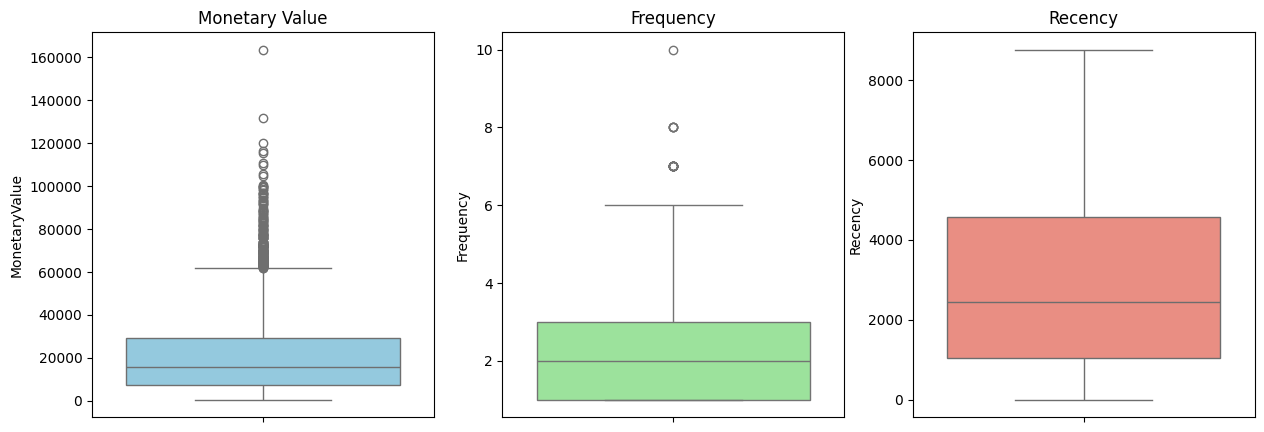

In [ ]:
# 4. Outlier Detection/Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=rfm_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value')
plt.subplot(1, 3, 2)
sns.boxplot(data=rfm_df['Frequency'], color='lightgreen')
plt.title('Frequency')
plt.subplot(1, 3, 3)
sns.boxplot(data=rfm_df['Recency'], color='salmon')
plt.title('Recency')
plt.show()

In [ ]:
# 5. Feature Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_df[['Recency', 'Frequency', 'MonetaryValue']])
rfm_scaled_df = pd.DataFrame(
    rfm_scaled, columns=['Recency', 'Frequency', 'MonetaryValue'])

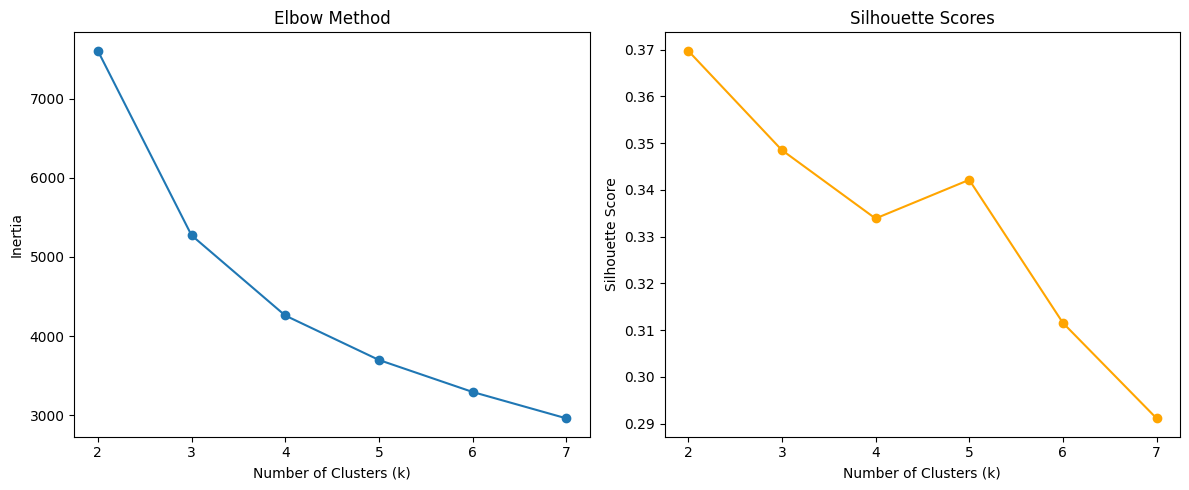

In [ ]:
# 6. Elbow & Silhouette Method for Optimal Clusters
inertia = []
silhouette_scores = []
k_values = range(2, 8)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(rfm_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled_df, cluster_labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()
plt.show()

In [ ]:
# 7. Run KMeans Clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
rfm_scaled_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# 8. Profile Clusters and Assign Labels
rfm_scaled_df['CustomerID'] = rfm_df['CustomerID']
full_df = pd.concat([rfm_df, rfm_scaled_df['Cluster']], axis=1)
cluster_summary = full_df.groupby(
    'Cluster')[['Recency', 'Frequency', 'MonetaryValue']].mean()
cluster_counts = full_df['Cluster'].value_counts()

cluster_labels = {
    0: 'RETAIN',
    1: 'RE-ENGAGE',
    2: 'GROWTH',
    3: 'NURTURE'
}
full_df['ClusterLabel'] = full_df['Cluster'].map(cluster_labels)

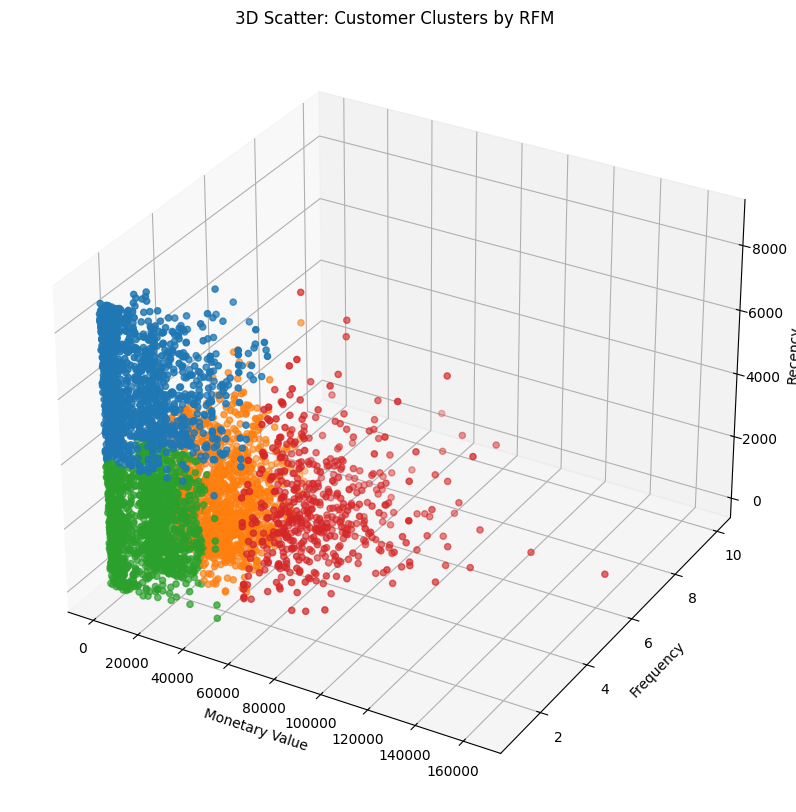

In [ ]:
# 8. Profile Clusters and Assign Labels
cluster_colors = {
    0: '#1f77b4',   # Blue
    1: '#ff7f0e',   # Orange
    2: '#2ca02c',   # Green
    3: '#d62728'    # Red
}
colors = full_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(
    full_df['MonetaryValue'],
    full_df['Frequency'],
    full_df['Recency'],
    c=colors,
    marker='o'
)
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter: Customer Clusters by RFM')
plt.show()

/var/folders/2r/mkqy3hkj5yn_vd4mxld8_h_r0000gn/T/ipykernel_7084/3168752290.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values,


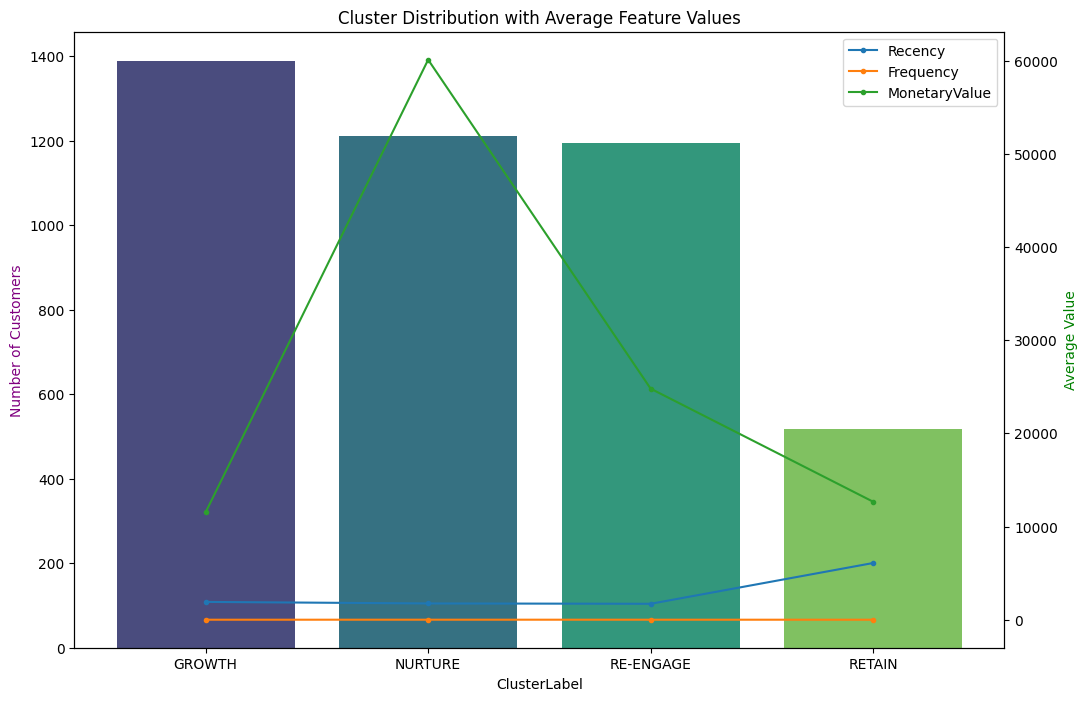

In [ ]:
# 10. Combo Cluster Distribution & Average Feature Values Plot
cluster_counts = full_df['ClusterLabel'].value_counts()
feature_means = full_df.groupby('ClusterLabel')[
    ['Recency', 'Frequency', 'MonetaryValue']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

# Bar plot for number of customers (y-axis: left)
sns.barplot(x=cluster_counts.index, y=cluster_counts.values,
            ax=ax1, palette='viridis')
ax1.set_ylabel('Number of Customers', color='purple')
ax1.set_xlabel('ClusterLabel')
ax1.set_title('Cluster Distribution with Average Feature Values')

# Secondary y-axis for average RFM values (y-axis: right)
ax2 = ax1.twinx()
feature_means.plot(ax=ax2, style='.-')
ax2.set_ylabel('Average Value', color='green')

plt.show()

/var/folders/2r/mkqy3hkj5yn_vd4mxld8_h_r0000gn/T/ipykernel_7084/1149701381.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=product_quantity.index,
/var/folders/2r/mkqy3hkj5yn_vd4mxld8_h_r0000gn/T/ipykernel_7084/1149701381.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=product_value.index, x=product_value.values, palette='Greens_d')


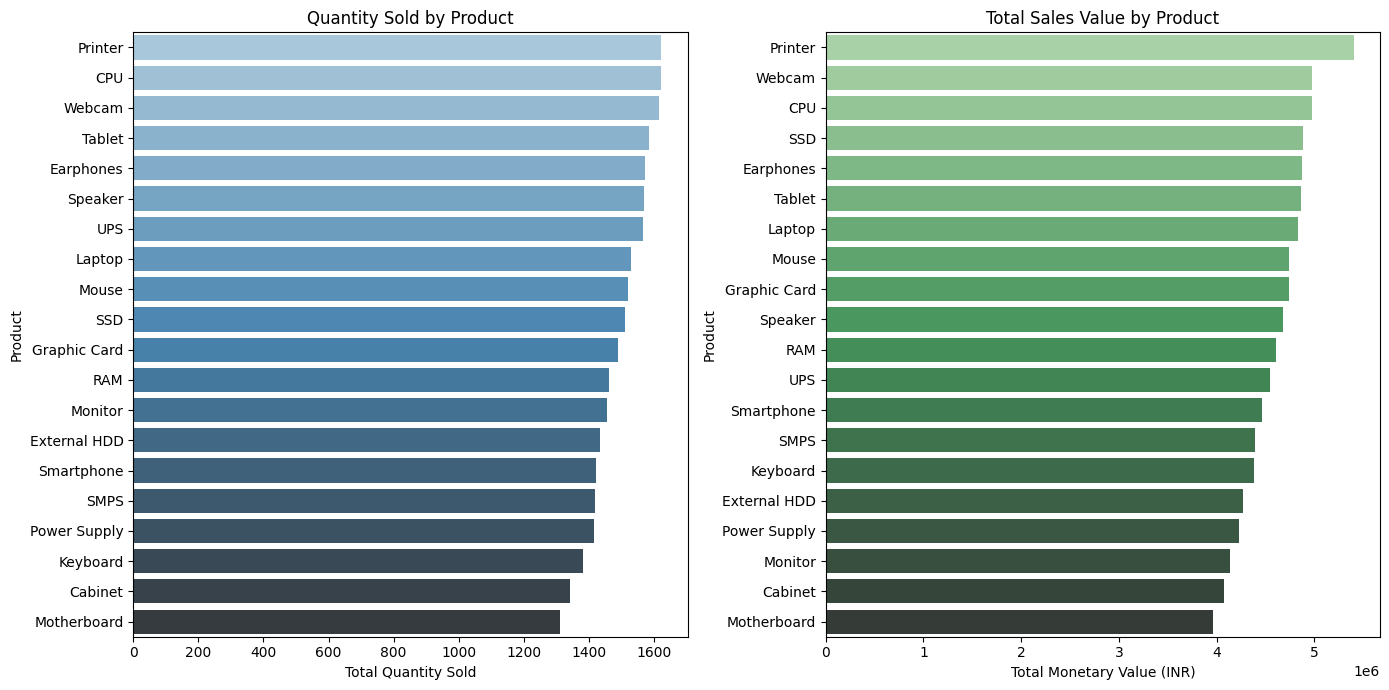

In [ ]:
# 11. Product Analytics – Most & Least Sold
import matplotlib.pyplot as plt
import seaborn as sns

# Group total quantity sold and total sales value by product
product_quantity = df.groupby(
    'Product')['Quantity'].sum().sort_values(ascending=False)
product_value = df.groupby(
    'Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.barplot(y=product_quantity.index,
            x=product_quantity.values, palette='Blues_d')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.title('Quantity Sold by Product')

plt.subplot(1, 2, 2)
sns.barplot(y=product_value.index, x=product_value.values, palette='Greens_d')
plt.xlabel('Total Monetary Value (INR)')
plt.ylabel('Product')
plt.title('Total Sales Value by Product')

plt.tight_layout()
plt.show()